In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


TensorFlow version: 2.19.0
Loading YAMNet model...
Starting the audio classification pipeline...
Processing dataset and extracting YAMNet embeddings...
Found 13 classes: ['car_horn', 'crying_baby', 'dog', 'door_knock', 'doorbell', 'fire_smoke_alarm', 'glass_breaking', 'gunshot', 'rain', 'screaming', 'siren', 'thunderstorm', 'train']
Processing 240 files in class 'car_horn'


100%|██████████| 240/240 [00:09<00:00, 24.75it/s]


Processing 240 files in class 'crying_baby'


100%|██████████| 240/240 [00:09<00:00, 25.93it/s]


Processing 240 files in class 'dog'


...

Processing 240 files in class 'thunderstorm'


100%|██████████| 240/240 [00:16<00:00, 14.68it/s]


Processing 240 files in class 'train'


100%|██████████| 240/240 [00:14<00:00, 16.62it/s]



Dataset summary:
Total samples: 3120
Feature dimension: 1024
Classes: ['car_horn', 'crying_baby', 'dog', 'door_knock', 'doorbell', 'fire_smoke_alarm', 'glass_breaking', 'gunshot', 'rain', 'screaming', 'siren', 'thunderstorm', 'train']

Training set: 2496 samples
Test set: 624 samples

Training classifiers...

Training Random Forest...
Random Forest Accuracy: 0.9920
Classification Report for Random Forest:
                  precision    recall  f1-score   support

        car_horn       1.00      0.98      0.99        48
     crying_baby       1.00      1.00      1.00        48
             dog       1.00      0.98      0.99        48
      door_knock       1.00      0.98      0.99        48
        doorbell       0.98      1.00      0.99        48
fire_smoke_alarm       0.98      0.98      0.98        48
  glass_breaking       0.98      1.00      0.99        48
         gunshot       1.00      1.00      1.00        48
            rain       1.00      1.00      1.00        48
       sc

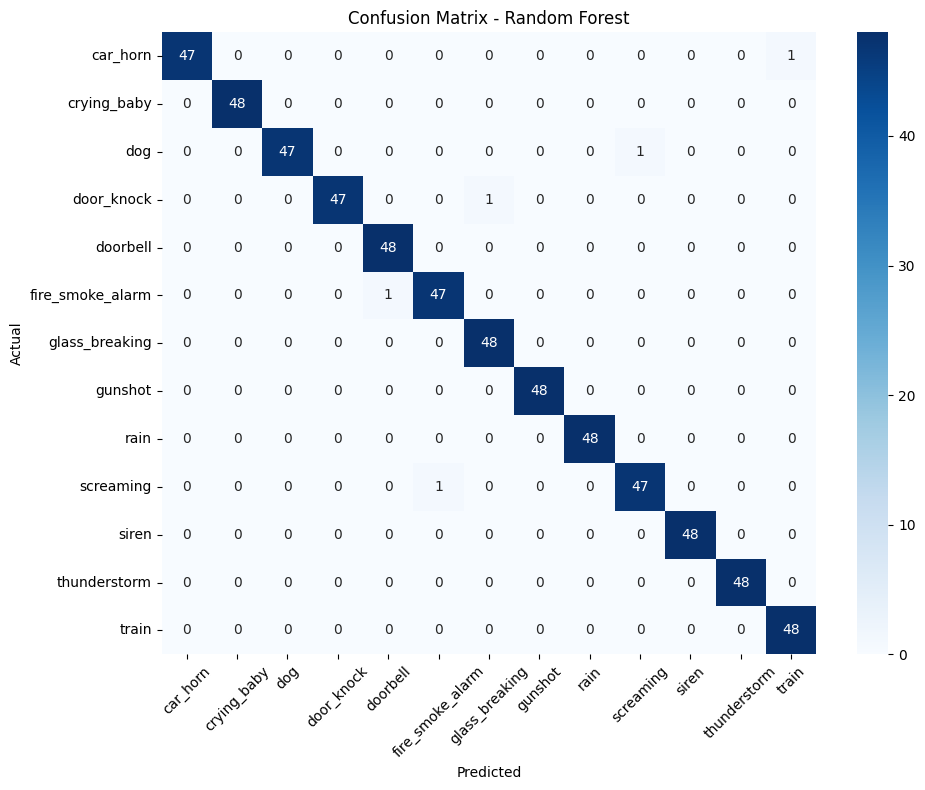


Training SVM...
SVM Accuracy: 0.9952
Classification Report for SVM:
                  precision    recall  f1-score   support

        car_horn       1.00      1.00      1.00        48
     crying_baby       1.00      1.00      1.00        48
             dog       0.96      0.98      0.97        48
      door_knock       1.00      1.00      1.00        48
        doorbell       1.00      0.96      0.98        48
fire_smoke_alarm       1.00      1.00      1.00        48
  glass_breaking       1.00      1.00      1.00        48
         gunshot       1.00      1.00      1.00        48
            rain       1.00      1.00      1.00        48
       screaming       0.98      1.00      0.99        48
           siren       1.00      1.00      1.00        48
    thunderstorm       1.00      1.00      1.00        48
           train       1.00      1.00      1.00        48

        accuracy                           1.00       624
       macro avg       1.00      1.00      1.00       624
 

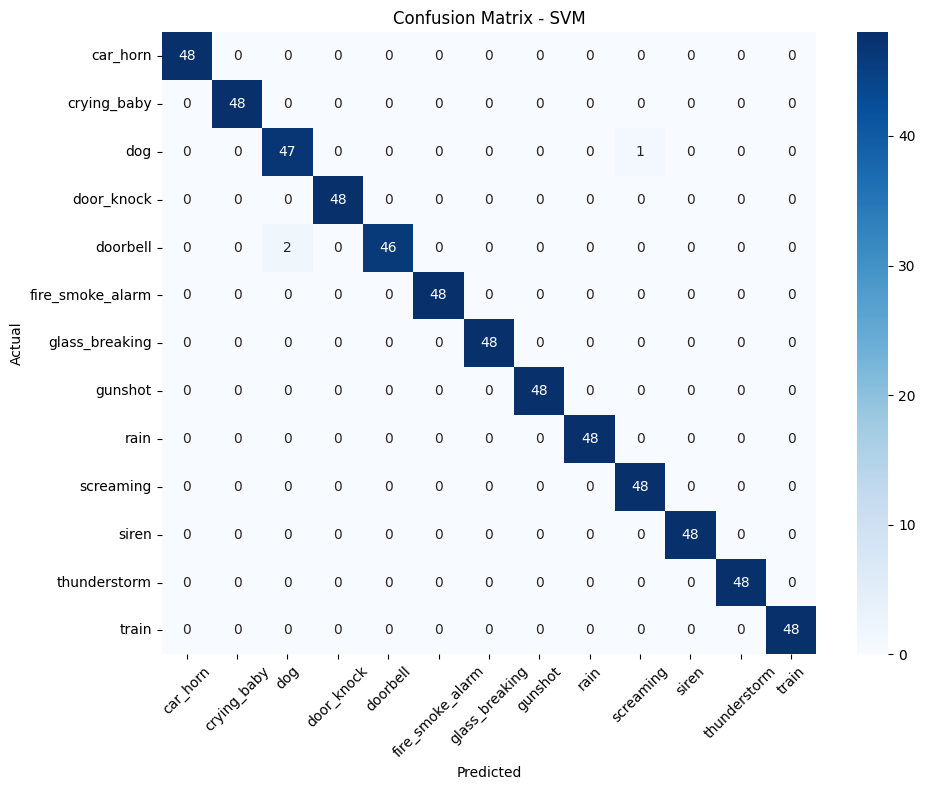


🎉 Best classifier: SVM with accuracy 0.9952

DEMO: TESTING WITH PRE-RECORDED AUDIO FILES
Found 3 test audio files:
  - /content/drive/MyDrive/Colab Notebooks/Main Project/crying-baby.wav
  - /content/drive/MyDrive/Colab Notebooks/Main Project/knocking-on-wood-door.wav
  - /content/drive/MyDrive/Colab Notebooks/Main Project/gun-fire-346766.wav

Testing 3 audio files

Testing pre-recorded audio: /content/drive/MyDrive/Colab Notebooks/Main Project/crying-baby.wav

Random Forest Results:
  🎯 Predicted Class: screaming
  📊 Confidence: 0.3200
  Top 3 predictions:
    1. screaming: 0.3200
    2. dog: 0.2200
    3. crying_baby: 0.1900
----------------------------------------

SVM Results:
  🎯 Predicted Class: screaming
  📊 Confidence: 0.5099
  Top 3 predictions:
    1. screaming: 0.5099
    2. dog: 0.1315
    3. siren: 0.1143
----------------------------------------

Testing pre-recorded audio: /content/drive/MyDrive/Colab Notebooks/Main Project/knocking-on-wood-door.wav

Random Forest Result

In [ ]:
# Install required packages
!pip install tensorflow tensorflow_hub librosa soundfile matplotlib scikit-learn

import tensorflow as tf
import tensorflow_hub as hub
import numpy as np
import librosa
import os
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
from tqdm import tqdm
import soundfile as sf

print("TensorFlow version:", tf.__version__)

# Load YAMNet model
print("Loading YAMNet model...")
yamnet_model = hub.load('/content/drive/MyDrive/YAMNet_Model')

# Function to extract YAMNet embeddings
def extract_yamnet_embedding(audio_data, sample_rate=16000):
    """
    Extract embeddings from YAMNet for audio data
    """
    # Ensure audio is at 16kHz (YAMNet requirement)
    if sample_rate != 16000:
        audio_data = librosa.resample(audio_data, orig_sr=sample_rate, target_sr=16000)
        sample_rate = 16000

    # YAMNet expects specific input format
    waveform = audio_data.astype(np.float32)

    # Get model outputs
    scores, embeddings, spectrogram = yamnet_model(waveform)

    # Return mean embedding across time frames
    return np.mean(embeddings, axis=0)

# Function to process audio files
def process_audio_files(dataset_path):
    """
    Process all audio files in the dataset and extract embeddings
    """
    features = []
    labels = []
    file_paths = []

    # Get all class folders
    classes = sorted([d for d in os.listdir(dataset_path)
                     if os.path.isdir(os.path.join(dataset_path, d))])

    print(f"Found {len(classes)} classes: {classes}")

    for class_idx, class_name in enumerate(classes):
        class_path = os.path.join(dataset_path, class_name)
        audio_files = [f for f in os.listdir(class_path)
                      if f.endswith(('.wav', '.mp3', '.flac', '.m4a'))]

        print(f"Processing {len(audio_files)} files in class '{class_name}'")

        for audio_file in tqdm(audio_files):
            audio_path = os.path.join(class_path, audio_file)

            try:
                # Load audio file
                audio_data, sample_rate = librosa.load(audio_path, sr=None)

                # Extract embedding
                embedding = extract_yamnet_embedding(audio_data, sample_rate)

                features.append(embedding)
                labels.append(class_idx)
                file_paths.append(audio_path)

            except Exception as e:
                print(f"Error processing {audio_path}: {e}")
                continue

    return np.array(features), np.array(labels), file_paths, classes

# Function to train and evaluate classifier
def train_classifier(X_train, X_test, y_train, y_test, classes):
    """
    Train and evaluate multiple classifiers
    """
    classifiers = {
        'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
        'SVM': SVC(kernel='linear', probability=True, random_state=42)
    }

    results = {}

    for name, clf in classifiers.items():
        print(f"\nTraining {name}...")
        clf.fit(X_train, y_train)

        # Predictions
        y_pred = clf.predict(X_test)
        y_pred_proba = clf.predict_proba(X_test)

        # Calculate accuracy
        accuracy = np.mean(y_pred == y_test)

        print(f"{name} Accuracy: {accuracy:.4f}")
        print(f"Classification Report for {name}:")
        print(classification_report(y_test, y_pred, target_names=classes))

        results[name] = {
            'classifier': clf,
            'accuracy': accuracy,
            'predictions': y_pred,
            'probabilities': y_pred_proba
        }

        # Plot confusion matrix
        plt.figure(figsize=(10, 8))
        cm = confusion_matrix(y_test, y_pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                   xticklabels=classes, yticklabels=classes)
        plt.title(f'Confusion Matrix - {name}')
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        plt.xticks(rotation=45)
        plt.yticks(rotation=0)
        plt.tight_layout()
        plt.show()

    return results

# Function to test with pre-recorded audio file
def test_pre_recorded_audio(audio_path, classifiers, classes, results):
    """
    Test a pre-recorded audio file with all trained classifiers
    """
    print(f"\nTesting pre-recorded audio: {audio_path}")
    print("=" * 60)

    try:
        # Load and process audio
        audio_data, sample_rate = librosa.load(audio_path, sr=None)

        # Extract embedding
        embedding = extract_yamnet_embedding(audio_data, sample_rate)
        embedding = embedding.reshape(1, -1)

        # Test with each classifier
        for name in classifiers:
            clf = results[name]['classifier']

            # Get prediction
            prediction = clf.predict(embedding)[0]
            probabilities = clf.predict_proba(embedding)[0]

            predicted_class = classes[prediction]
            confidence = probabilities[prediction]

            print(f"\n{name} Results:")
            print(f"  🎯 Predicted Class: {predicted_class}")
            print(f"  📊 Confidence: {confidence:.4f}")

            # Show top 3 predictions
            top_3_idx = np.argsort(probabilities)[-3:][::-1]
            print("  Top 3 predictions:")
            for i, idx in enumerate(top_3_idx):
                print(f"    {i+1}. {classes[idx]}: {probabilities[idx]:.4f}")

            print("-" * 40)

    except Exception as e:
        print(f"Error testing audio {audio_path}: {e}")

# Function to test multiple pre-recorded files at once
def test_multiple_audio_files(audio_files_list, classifiers, classes, results):
    """
    Test multiple pre-recorded audio files
    """
    print(f"\nTesting {len(audio_files_list)} audio files")
    print("=" * 60)

    for audio_path in audio_files_list:
        if os.path.exists(audio_path):
            test_pre_recorded_audio(audio_path, classifiers, classes, results)
        else:
            print(f"File not found: {audio_path}")

# Function to upload and test audio files in Colab
def upload_and_test_audio(classifiers, classes, results):
    """
    Upload audio files and test them
    """
    from google.colab import files

    print("Upload audio files for testing...")
    uploaded = files.upload()

    for filename in uploaded.keys():
        test_pre_recorded_audio(filename, classifiers, classes, results)

# Main execution
def main():
    # Set your dataset path
    dataset_path = "/content/drive/MyDrive/Colab Notebooks/Main Project/augmented_audio"  # Change this to your path

    # Process dataset and extract features
    print("Processing dataset and extracting YAMNet embeddings...")
    X, y, file_paths, classes = process_audio_files(dataset_path)

    print(f"\nDataset summary:")
    print(f"Total samples: {len(X)}")
    print(f"Feature dimension: {X.shape[1]}")
    print(f"Classes: {classes}")

    # Split dataset
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    print(f"\nTraining set: {X_train.shape[0]} samples")
    print(f"Test set: {X_test.shape[0]} samples")

    # Train classifiers
    print("\nTraining classifiers...")
    results = train_classifier(X_train, X_test, y_train, y_test, classes)

    # Find best classifier
    best_classifier = max(results.items(), key=lambda x: x[1]['accuracy'])
    print(f"\n🎉 Best classifier: {best_classifier[0]} with accuracy {best_classifier[1]['accuracy']:.4f}")

    return results, classes, X, y

# Run the main pipeline
print("Starting the audio classification pipeline...")
results, classes, X, y = main()

# DEMO: Test with pre-recorded audio files
print("\n" + "="*60)
print("DEMO: TESTING WITH PRE-RECORDED AUDIO FILES")
print("="*60)

# Example 1: Test with specific file paths
demo_audio_files = [
    "/content/drive/MyDrive/Colab Notebooks/Main Project/crying-baby.wav",
    "/content/drive/MyDrive/Colab Notebooks/Main Project/knocking-on-wood-door.wav",
    "/content/drive/MyDrive/Colab Notebooks/Main Project/gun-fire-346766.wav"
]

# Remove files that don't exist and show available ones
available_files = [f for f in demo_audio_files if os.path.exists(f)]
if available_files:
    print(f"Found {len(available_files)} test audio files:")
    for f in available_files:
        print(f"  - {f}")

    # Test the available files
    test_multiple_audio_files(available_files, results.keys(), classes, results)
else:
    print("No demo files found at specified paths.")
    print("Please update the 'demo_audio_files' list with your actual file paths.")








FEATURE IMPORTANCE ANALYSIS


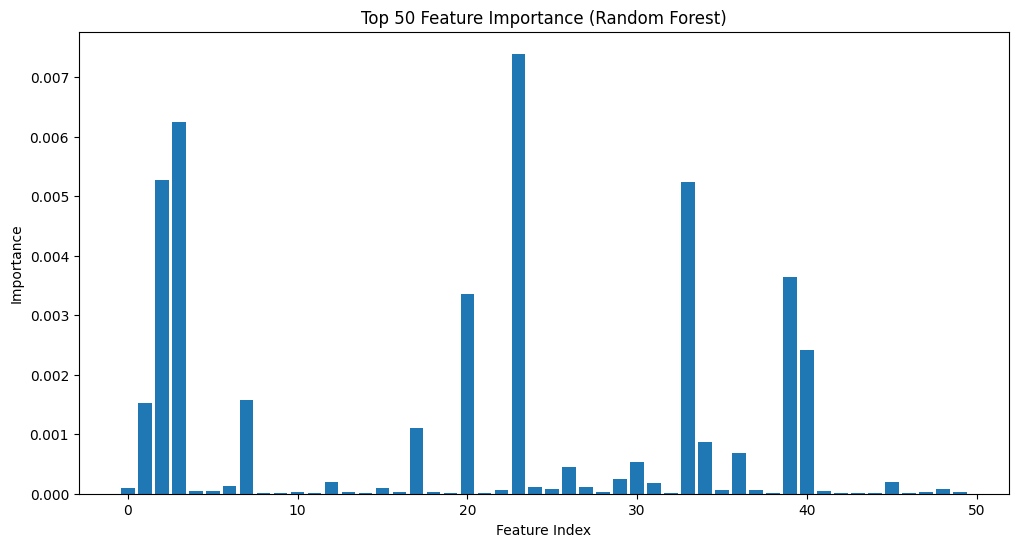

Top 10 most important features: [1008   75  663  521  389  104  218  435  317  929]

SETUP COMPLETE!

You can now test pre-recorded audio files using:
1. test_pre_recorded_audio('path/to/audio.wav', results.keys(), classes, results)
2. test_multiple_audio_files([list_of_paths], results.keys(), classes, results)
3. upload_and_test_audio(results.keys(), classes, results) - for Colab uploads

Example usage:
test_pre_recorded_audio('/content/my_smoke_alarm.wav', results.keys(), classes, results)


In [ ]:

# Save the trained model for later use
import joblib

def save_models(results, classes):
    """Save trained models and class information"""
    for name, result in results.items():
        model = result['classifier']
        filename = f'{name.lower().replace(" ", "_")}_model.pkl'
        joblib.dump(model, filename)
        print(f"Saved {filename}")

    # Save class information
    np.save('classes.npy', classes)
    print("Classes saved to classes.npy")
    print("All models saved successfully!")

# Save models (uncomment to use)
# save_models(results, classes)

# Load saved models (for future use)
def load_models():
    """Load saved models and class information"""
    classes = np.load('classes.npy', allow_pickle=True)

    results = {}
    model_files = {
        'Random Forest': 'random_forest_model.pkl',
        'SVM': 'svm_model.pkl'
    }

    for name, file in model_files.items():
        if os.path.exists(file):
            results[name] = {
                'classifier': joblib.load(file),
                'accuracy': None
            }
            print(f"Loaded {file}")

    return results, classes

# Feature importance analysis (for Random Forest)
if 'Random Forest' in results:
    print("\n" + "="*60)
    print("FEATURE IMPORTANCE ANALYSIS")
    print("="*60)

    rf_model = results['Random Forest']['classifier']
    feature_importance = rf_model.feature_importances_

    plt.figure(figsize=(12, 6))
    plt.bar(range(50), feature_importance[:50])  # Show top 50 features
    plt.title('Top 50 Feature Importance (Random Forest)')
    plt.xlabel('Feature Index')
    plt.ylabel('Importance')
    plt.show()

    top_10_features = np.argsort(feature_importance)[-10:][::-1]
    print(f"Top 10 most important features: {top_10_features}")

print("\n" + "="*60)
print("SETUP COMPLETE!")
print("="*60)
print("\nYou can now test pre-recorded audio files using:")
print("1. test_pre_recorded_audio('path/to/audio.wav', results.keys(), classes, results)")
print("2. test_multiple_audio_files([list_of_paths], results.keys(), classes, results)")
print("3. upload_and_test_audio(results.keys(), classes, results) - for Colab uploads")
print("\nExample usage:")
print("test_pre_recorded_audio('/content/my_smoke_alarm.wav', results.keys(), classes, results)")

In [ ]:
# Simplest method - just run this cell
from google.colab import files
import joblib
import numpy as np

# Ensure models are saved
save_models(results, classes)

# Download files one by one
try:
    files.download('random_forest_model.pkl')
    files.download('svm_model.pkl')
    files.download('classes.npy')
    print("All files downloaded successfully!")
except Exception as e:
    print(f"Download error: {e}")

Saved random_forest_model.pkl
Saved svm_model.pkl
Classes saved to classes.npy
All models saved successfully!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

All files downloaded successfully!


In [ ]:
def test_single_audio(audio_path, results, classes):
    """
    Test a single pre-recorded audio file using your trained classifiers
    """
    from pathlib import Path
    if not Path(audio_path).exists():
        print(f"File not found: {audio_path}")
        return

    print(f"\nTesting: {audio_path}")

    # Load audio
    audio_data, sample_rate = librosa.load(audio_path, sr=None)

    # Extract embedding
    embedding = extract_yamnet_embedding(audio_data, sample_rate)
    embedding = embedding.reshape(1, -1)

    # Test with all classifiers
    for name in results.keys():
        clf = results[name]['classifier']
        pred = clf.predict(embedding)[0]
        pred_proba = clf.predict_proba(embedding)[0]
        predicted_class = classes[pred]
        confidence = pred_proba[pred]

        # Top 3 predictions
        top3_idx = np.argsort(pred_proba)[-3:][::-1]
        print(f"\n{name} Results:")
        print(f"  🎯 Predicted Class: {predicted_class}")
        print(f"  📊 Confidence: {confidence:.4f}")
        print("  Top 3 predictions:")
        for i, idx in enumerate(top3_idx):
            print(f"    {i+1}. {classes[idx]}: {pred_proba[idx]:.4f}")
        print("-"*40)

# Example usage
test_single_audio("/content/drive/MyDrive/Colab Notebooks/Main Project/crying-baby.wav", results, classes)



Testing: /content/drive/MyDrive/Colab Notebooks/Main Project/crying-baby.wav

Random Forest Results:
  🎯 Predicted Class: screaming
  📊 Confidence: 0.3200
  Top 3 predictions:
    1. screaming: 0.3200
    2. dog: 0.2200
    3. crying_baby: 0.1900
----------------------------------------

SVM Results:
  🎯 Predicted Class: screaming
  📊 Confidence: 0.5099
  Top 3 predictions:
    1. screaming: 0.5099
    2. dog: 0.1315
    3. siren: 0.1143
----------------------------------------


realtime
